In [1]:
!python -m pip install pandas corus nltk scikit-learn seaborn matplotlib gensim navec pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 11.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pymorphy3]


# Библиотеки + сид

In [1]:
import re
import os
import urllib.request
import pymorphy3

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import numpy as np
from corus import load_lenta

from gensim.models import Word2Vec
from gensim.models import KeyedVectors

from functools import lru_cache

from navec import Navec

from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

In [2]:
RANDOM_STATE = 24

# EDA

In [3]:
path = 'lenta-ru-news.csv.gz' 
records = load_lenta(path)

data =[]
for record in records:
    data.append({
        'title': record.title,
        'text': record.text,
        'topic': record.topic
    })
    
df = pd.DataFrame(data)

Посмотрим сколько у нас пустых топиков и удалим их

In [4]:
initial_count = len(df)
print(f"Всего записей {initial_count}")

df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

print("\nПропуски")
print(df.isna().sum())

Всего записей 739351

Пропуски
title      0
text       5
topic    203
dtype: int64


In [5]:
df = df.dropna(subset=['topic'])

Посмотрим на распределение новостей по каждой теме

topic
Россия               160519
Мир                  136680
Экономика             79538
Спорт                 64421
Культура              53803
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44675
Из жизни              27611
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64


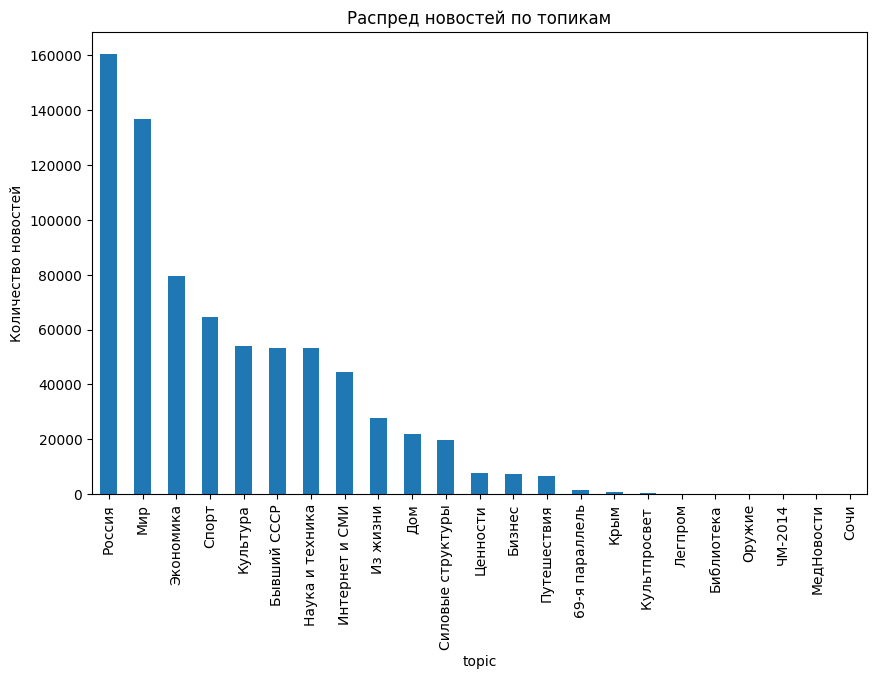

In [6]:
topic_counts = df['topic'].value_counts()
print(topic_counts)

plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar')
plt.title('Распред новостей по топикам')
plt.ylabel('Количество новостей')
plt.show()

Мне часто высвечивался warning при разделении данных в сплитах, мол слишком мало новостей для какого-то топика (stratify жаловался). Принял решение отсеять топики по кол-ву новостей

In [7]:
counts = df['topic'].value_counts()
valid_topics = counts[counts >= 100].index

df_clean = df[df['topic'].isin(valid_topics)]

print("Размер", df_clean.shape)

Размер (739076, 3)


Берем 100к текстов, так как ТЗ

In [8]:
df_sample, _ = train_test_split(
    df_clean,
    train_size=100000, 
    random_state=RANDOM_STATE, 
    stratify=df_clean['topic']
)

df_sample = df_sample.reset_index(drop=True)

print("Размер", df_sample.shape)

Размер (100000, 3)


1) сделал очистику и нормализацию от знаков препинания, цифр и так далее через регулярки
2) скачал стоп слова на русском и удалил их (это предлоги, местоимения и так далее)
3) слил заголовок и описание текста, мне кажется это даст больше информативности, хотя без этой фичи я не тестил
4) Я отказался от стемминга, так как rusvectores бы упал и показывало очень низкое качество. Я хотел сделать вообще без лемминга и стемиинга, но результаты для rusvectores были плохие. Пришлось сделать лемминг. В 1-ой ЛР я сказал, что лемминг долгий и по факту это так. Но оказывается можно ускорить за счет `@lry_cache` и теперь у меня леммизация отработала быстрее стемминга в 3 раза... No comments

In [9]:
morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words('russian'))

@lru_cache(maxsize=100000)
def get_lemma(word):
    return morph.parse(word)[0].normal_form

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё]', ' ', text)
    tokens = text.split()
    
    tokens = [get_lemma(word) for word in tokens]
    tokens = [word for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

df_sample['full_text'] = df_sample['title'] + " " + df_sample['text']

df_sample['processed_text'] = df_sample['full_text'].apply(preprocess_text)

Базовая разбивка также по ТЗ

In [10]:
X = df_sample['processed_text']
y = df_sample['topic']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.4, 
    random_state=RANDOM_STATE, 
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=RANDOM_STATE, 
    stratify=y_temp
)

# Обучение моделей

## word2vec

Гипепараметры:
1) `vector_size` 300, вроде дефолт
2) окно с размером 5, тоже вроде дефолт
3) `min_count` чтобы выкинуть редкие слова

In [36]:
sentences_train = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=sentences_train, 
    vector_size=300, 
    window=5, 
    min_count=5, 
    workers=4, 
    seed=RANDOM_STATE
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [12]:
print("Ближайшие к 'деньга'\n", w2v_model.wv.most_similar('деньга'))

Ближайшие к 'деньга'
 [('средство', 0.7141640782356262), ('пожертвование', 0.6394808292388916), ('вознаграждение', 0.5310320854187012), ('наличный', 0.5076733231544495), ('сбережение', 0.5023366808891296), ('заём', 0.49934613704681396), ('субсидия', 0.4961254298686981), ('пфр', 0.4881175458431244), ('мошенник', 0.48489439487457275), ('наличные', 0.4839508831501007)]


`Пожертвование` топ 2... Почему...

In [13]:
print("Ближайшие к 'полиция'\n", w2v_model.wv.most_similar('полиция'))

Ближайшие к 'полиция'
 [('полицейский', 0.7319517731666565), ('милиция', 0.674948513507843), ('правоохранитель', 0.5656605362892151), ('ровд', 0.520889163017273), ('правоохранительный', 0.5019195079803467), ('фбр', 0.5011226534843445), ('милиционер', 0.4915943145751953), ('правопорядок', 0.4861964285373688), ('гибдд', 0.4825045168399811), ('спецслужба', 0.4812272787094116)]


In [14]:
print("Ближайшие к 'рубль'\n", w2v_model.wv.most_similar('рубль'))

Ближайшие к 'рубль'
 [('доллар', 0.6847362518310547), ('гривна', 0.6593412756919861), ('евро', 0.6423404812812805), ('декалитр', 0.534925103187561), ('суммарно', 0.530191957950592), ('кубометр', 0.5258108377456665), ('шекель', 0.5217569470405579), ('песо', 0.5015048980712891), ('манат', 0.4920201599597931), ('иена', 0.4841511845588684)]


In [37]:
print("\nЛишнее слово", w2v_model.wv.doesnt_match(['полиция', 'арбуз', 'деньги', 'бандиты']))


Лишнее слово арбуз


Бедный арбуз... Но вообще логично вроде

## Качаем navec + rusvectors

In [16]:
!curl -L -O https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 25.4M  100 25.4M    0     0  7159k      0  0:00:03  0:00:03 --:--:-- 7159k


In [16]:
path_navec = 'navec_news_v1_1B_250K_300d_100q.tar'
navec = Navec.load(path_navec)

In [18]:
!curl -L -O http://vectors.nlpl.eu/repository/11/180.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  462M  100  462M    0     0   470k      0  0:16:45  0:16:45 --:--:--  624k  0  30642      0  4:23:30  0:00:01  4:23:29 30633    0  11058      0 12:10:10  0:00:20 12:09:50 16066:52:13  0:00:34 13:51:39  8317 0 14:13:25  0:00:45 14:12:40 133479491      0 14:10:43  0:00:50 14:09:53  9750    0  23511      0  5:43:25  0:01:05  5:42:20  195k  124k      0  1:03:23  0:01:22  1:02:01  384k:02:12  0:30:29     08k      0  0:34:34  0:02:20  0:32:14  6155:01  0:02:34  0:35:27  68862M    0     0   206k      0  0:38:12  0:02:35  0:35:37  6251   0     0   200k      0  0:39:15  0:02:39  0:36:36  6894 202k      0  0:38:51  0:03:21  0:35:30  641k8M    0     0   218k      0  0:36:03  0:03:30  0:32:33  609k30  0:25:20  9108k      0  0:29:43  0:05:17  0:24:26 2148kk      0  0:28:19  0:05:18  0:23:01 2707k  0  0:23:24  0:05:31  0:17:53 1016k      0 

In [19]:
!unzip 180.zip -d rusvectores_model

Archive:  180.zip
  inflating: rusvectores_model/README  
  inflating: rusvectores_model/meta.json  
  inflating: rusvectores_model/model.bin  
  inflating: rusvectores_model/model.txt  


In [17]:
path_rusvectores = 'rusvectores_model/model.bin' 

rusvectores = KeyedVectors.load_word2vec_format(path_rusvectores, binary=True)

In [18]:
print(list(rusvectores.key_to_index.keys())[:5])

['так_ADV', 'быть_VERB', 'мочь_VERB', 'год_NOUN', 'человек_NOUN']


## Обучение трех разных моделей

Для navec+w2v просто делаем mean по всем векторам слов

а для rusvectores в силу его особенности (так_ADV) для каждого слова в моменте будет добавлять этот тег из самых частых. И тут тоже делаем mean по всем векторам слов

In [19]:
def get_text_embedding(text, model, emb_type='w2v', vector_size=300):
    tokens = str(text).split()
    vectors =[]
    
    for token in tokens:
        if emb_type == 'w2v':
            if token in model.wv:
                vectors.append(model.wv[token])
                
        elif emb_type == 'navec':
            if token in model.vocab:
                vectors.append(model[token])
                
        elif emb_type == 'rusvectores':
            for pos in['_NOUN', '_VERB', '_ADJ', '_PROPN', '_ADV']:
                if token + pos in model:
                    vectors.append(model[token + pos])
                    break
                    
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

In [20]:
X_train_w2v = np.array([get_text_embedding(text, w2v_model, 'w2v') for text in X_train])
X_val_w2v   = np.array([get_text_embedding(text, w2v_model, 'w2v') for text in X_val])

In [21]:
X_train_navec = np.array([get_text_embedding(text, navec, 'navec') for text in X_train])
X_val_navec   = np.array([get_text_embedding(text, navec, 'navec') for text in X_val])

In [22]:
X_train_rusv = np.array([get_text_embedding(text, rusvectores, 'rusvectores') for text in X_train])
X_val_rusv   = np.array([get_text_embedding(text, rusvectores, 'rusvectores') for text in X_val])

### Word2Vec

In [23]:
lr_w2v = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
lr_w2v.fit(X_train_w2v, y_train)

preds_w2v = lr_w2v.predict(X_val_w2v)
print("Word2Vec")
print(classification_report(y_val, preds_w2v, zero_division=0))

Word2Vec
                   precision    recall  f1-score   support

   69-я параллель       0.50      0.15      0.23        34
           Бизнес       0.33      0.09      0.14       200
      Бывший СССР       0.77      0.74      0.75      1445
              Дом       0.81      0.78      0.80       589
         Из жизни       0.62      0.58      0.60       747
   Интернет и СМИ       0.73      0.69      0.71      1209
             Крым       0.25      0.06      0.09        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.86      0.86      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.77      0.81      0.79      3698
  Наука и техника       0.79      0.80      0.79      1438
      Путешествия       0.67      0.53      0.60       174
           Россия       0.75      0.79      0.77      4344
Силовые структуры       0.51      0.26      0.35       530
            Спорт       0.96      0.96      0.

recall конечно бедолага

### Navec

In [24]:
lr_navec = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
lr_navec.fit(X_train_navec, y_train)

preds_navec = lr_navec.predict(X_val_navec)
print("Navec")
print(classification_report(y_val, preds_navec, zero_division=0))

Navec
                   precision    recall  f1-score   support

   69-я параллель       0.80      0.12      0.21        34
           Бизнес       0.46      0.10      0.16       200
      Бывший СССР       0.79      0.76      0.77      1445
              Дом       0.83      0.78      0.81       589
         Из жизни       0.63      0.56      0.59       747
   Интернет и СМИ       0.73      0.70      0.71      1209
             Крым       0.00      0.00      0.00        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.88      0.86      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.77      0.83      0.80      3698
  Наука и техника       0.79      0.79      0.79      1438
      Путешествия       0.67      0.49      0.57       174
           Россия       0.74      0.80      0.77      4344
Силовые структуры       0.47      0.22      0.30       530
            Спорт       0.96      0.96      0.96 

в общем и целом также как и w2v

### Rusvectores

In [25]:
lr_rusv = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
lr_rusv.fit(X_train_rusv, y_train)

preds_rusv = lr_rusv.predict(X_val_rusv)
print("Rusvectores")
print(classification_report(y_val, preds_rusv, zero_division=0))

Rusvectores
                   precision    recall  f1-score   support

   69-я параллель       0.38      0.24      0.29        34
           Бизнес       0.33      0.12      0.18       200
      Бывший СССР       0.71      0.64      0.68      1445
              Дом       0.78      0.77      0.77       589
         Из жизни       0.61      0.54      0.57       747
   Интернет и СМИ       0.70      0.66      0.68      1209
             Крым       0.33      0.11      0.17        18
    Культпросвет        0.50      0.11      0.18         9
         Культура       0.84      0.86      0.85      1456
          Легпром       1.00      0.67      0.80         3
              Мир       0.75      0.80      0.78      3698
  Наука и техника       0.76      0.77      0.77      1438
      Путешествия       0.61      0.52      0.57       174
           Россия       0.72      0.76      0.74      4344
Силовые структуры       0.46      0.24      0.31       530
            Спорт       0.95      0.95     

тут pr+rc явно выше, так что буду брать rusvectores за основу улучшения

## Улучшение модели

Я запускал без гиперпарметров, но там получились печальные результаты (хотя даже с гиперпараметрами ситуация не лучше xD)

взял так:
1) `min_df` чтобы убрать редкий мусор
2) `max_df`чтобы убрать часто встречаемый мусор

In [26]:
tfidf = TfidfVectorizer(min_df=10, max_df=0.7)
tfidf.fit(X_train)

idf_dict = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

In [38]:
def get_weighted_embedding(text, model, idf_dict, emb_type='w2v', vector_size=300):
    tokens = str(text).split()
    vectors = []
    weights =[]
    
    for token in tokens:
        if token not in idf_dict:
            continue
            
        weight = idf_dict[token]
        
        if emb_type == 'w2v':
            if token in model.wv:
                vectors.append(model.wv[token])
                weights.append(weight)
                
        elif emb_type == 'navec':
            if token in model.vocab:
                vectors.append(model[token])
                weights.append(weight)
                
        elif emb_type == 'rusvectores':
            for pos in['_NOUN', '_VERB', '_ADJ', '_PROPN', '_ADV']:
                if token + pos in model:
                    vectors.append(model[token + pos])
                    weights.append(weight)
                    break
                    
    if len(vectors) > 0:
        return np.average(vectors, axis=0, weights=weights)
    else:
        return np.zeros(vector_size)

In [39]:
X_train_weighted = np.array([get_weighted_embedding(text, w2v_model, idf_dict, emb_type='w2v') for text in X_train])
X_val_weighted   = np.array([get_weighted_embedding(text, w2v_model, idf_dict, emb_type='w2v') for text in X_val])

In [40]:
lr_weighted = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
lr_weighted.fit(X_train_weighted, y_train)

print("TFIDF")
print(classification_report(y_val, lr_weighted.predict(X_val_weighted), zero_division=0))

TFIDF
                   precision    recall  f1-score   support

   69-я параллель       0.62      0.15      0.24        34
           Бизнес       0.38      0.09      0.15       200
      Бывший СССР       0.78      0.75      0.76      1445
              Дом       0.83      0.80      0.81       589
         Из жизни       0.61      0.57      0.59       747
   Интернет и СМИ       0.73      0.68      0.71      1209
             Крым       0.33      0.06      0.10        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.87      0.86      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.77      0.82      0.80      3698
  Наука и техника       0.79      0.81      0.80      1438
      Путешествия       0.62      0.52      0.57       174
           Россия       0.75      0.80      0.77      4344
Силовые структуры       0.49      0.25      0.33       530
            Спорт       0.96      0.96      0.96 

ОКАК

Получилось хуже чем без TFIDF

# Сравнение моделей

In [30]:
X_test_w2v = np.array([get_text_embedding(text, w2v_model, 'w2v') for text in X_test])
print("Word2Vec")
print(classification_report(y_test, lr_w2v.predict(X_test_w2v), zero_division=0))

Word2Vec
                   precision    recall  f1-score   support

   69-я параллель       0.71      0.14      0.24        35
           Бизнес       0.44      0.13      0.20       200
      Бывший СССР       0.78      0.73      0.76      1445
              Дом       0.81      0.75      0.78       588
         Из жизни       0.61      0.55      0.57       748
   Интернет и СМИ       0.71      0.68      0.69      1209
             Крым       0.50      0.17      0.25        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.85      0.85      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.78      0.81      0.80      3699
  Наука и техника       0.77      0.79      0.78      1438
      Путешествия       0.67      0.59      0.63       173
           Россия       0.74      0.80      0.77      4344
Силовые структуры       0.50      0.30      0.37       530
            Спорт       0.95      0.96      0.

In [31]:
X_test_navec = np.array([get_text_embedding(text, navec, 'navec') for text in X_test])
print("Navec")
print(classification_report(y_test, lr_navec.predict(X_test_navec), zero_division=0))

Navec
                   precision    recall  f1-score   support

   69-я параллель       0.88      0.20      0.33        35
           Бизнес       0.45      0.10      0.16       200
      Бывший СССР       0.78      0.75      0.77      1445
              Дом       0.80      0.76      0.78       588
         Из жизни       0.60      0.53      0.56       748
   Интернет и СМИ       0.72      0.69      0.71      1209
             Крым       0.00      0.00      0.00        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.86      0.85      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.78      0.82      0.80      3699
  Наука и техника       0.77      0.80      0.78      1438
      Путешествия       0.66      0.51      0.58       173
           Россия       0.75      0.81      0.78      4344
Силовые структуры       0.52      0.26      0.34       530
            Спорт       0.96      0.96      0.96 

In [32]:
X_test_rusv = np.array([get_text_embedding(text, rusvectores, 'rusvectores') for text in X_test])
print("Rusvectores")
print(classification_report(y_test, lr_rusv.predict(X_test_rusv), zero_division=0))

Rusvectores
                   precision    recall  f1-score   support

   69-я параллель       0.50      0.26      0.34        35
           Бизнес       0.37      0.12      0.17       200
      Бывший СССР       0.71      0.64      0.67      1445
              Дом       0.79      0.74      0.76       588
         Из жизни       0.59      0.54      0.56       748
   Интернет и СМИ       0.69      0.66      0.67      1209
             Крым       0.29      0.11      0.16        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.84      0.86      0.85      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.76      0.79      0.77      3699
  Наука и техника       0.76      0.77      0.77      1438
      Путешествия       0.67      0.57      0.61       173
           Россия       0.71      0.77      0.74      4344
Силовые структуры       0.43      0.25      0.32       530
            Спорт       0.95      0.95     

In [42]:
X_test_weighted = np.array([get_weighted_embedding(text, w2v_model, idf_dict, emb_type='w2v') for text in X_test])
print("TFIDF")
print(classification_report(y_test, lr_weighted.predict(X_test_weighted), zero_division=0))

TFIDF
                   precision    recall  f1-score   support

   69-я параллель       0.75      0.17      0.28        35
           Бизнес       0.44      0.13      0.20       200
      Бывший СССР       0.78      0.73      0.75      1445
              Дом       0.80      0.75      0.78       588
         Из жизни       0.60      0.54      0.57       748
   Интернет и СМИ       0.70      0.69      0.69      1209
             Крым       0.67      0.11      0.19        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.86      0.86      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.78      0.82      0.80      3699
  Наука и техника       0.78      0.80      0.79      1438
      Путешествия       0.66      0.55      0.60       173
           Россия       0.75      0.80      0.77      4344
Силовые структуры       0.51      0.30      0.38       530
            Спорт       0.96      0.95      0.95 

Честно говоря выводы неутешительны. Нельзя кого-то выделить, все как-то одинаковы. Наверное больше всех понравился W2V, так как это свое, обученное на текущем тексте, а все остальное ну просто словари готовые, особенно rusvectores проблемный, так как у него еще теги для слов и это ужас какой-то в данном кейсе. 

TFIDF тоже не выстрелил, такой же результат по сути. Да, конечно, на каких-то топиках он показал себя лучше, но мне кажется это не значимо. 